# Этот ноутбук содержит в себе визуализации кластеров из объединённого датафрейма АПК + химия

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils.vis import plot_tsne_similarity, plot_tsne_similarity_plotly
from utils.misc import save_dict_as_json
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
df1 = pd.read_csv("/home/danilach/mipt-stats/SberTs/Data/apk_nona.csv", index_col=0)
df1.index = pd.to_datetime(df1.index)
df2 = pd.read_csv(
    "/home/danilach/mipt-stats/SberTs/Data/chemicals_nona.csv", index_col=0
)
df2.index = pd.to_datetime(df2.index)

In [3]:
df = pd.concat([df1[24:], df2[:-1]], axis=1)
print(len(df.columns))

51


In [4]:
df

,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,Сахар (средняя цена по России),...,Карбамид (FOB Южный),"Моноаммонийфосфат, MAP (FOB Балтика)",Апатитовый концетрат (FOB Morocco),Аммиак (FOB Черное море),Аммиачная селитра (FOB Черное море),Хлорид калия (CFR Ю-В Азия),Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия,Метанол,"Бензол, CFR Япония","Этилен, CFR Китай"
2016-01-01,77.1504,7.78479,21.90863,68.46276,98.09368,23.065100,9.152530,9.823100,8.468390,37.847160,...,209.875000,366.25,120.0,266.666667,199.375,278.750,1153.000000,185.40,556.000000,987.500000
2016-02-01,77.2096,8.96166,21.93128,71.09693,95.96070,25.004510,10.344510,10.189000,9.031580,38.852860,...,207.125000,332.50,117.5,260.500000,182.125,272.500,1163.000000,150.00,546.250000,927.500000
2016-03-01,69.8752,8.62014,21.92008,72.08125,98.69213,24.905110,6.091980,10.360780,8.948070,38.674850,...,199.875000,345.00,117.5,267.500000,180.300,267.500,1290.000000,164.75,625.000000,1173.750000
2016-04-01,66.4805,8.72565,21.71031,67.15105,99.12532,23.893940,11.492900,10.144230,8.972940,37.198530,...,203.875000,346.25,115.0,271.000000,172.000,267.500,1355.000000,179.90,642.000000,1192.500000
2016-05-01,65.9479,8.86495,21.32462,69.34780,98.50837,22.985290,10.565500,9.918600,9.077650,37.418730,...,200.500000,341.50,107.5,279.250000,154.750,251.875,1278.000000,201.25,631.250000,1160.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,52.162194,...,347.800000,575.00,155.0,513.817188,255.800,300.000,1440.000000,422.10,915.000000,873.333333
2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,53.022727,...,387.000000,585.25,155.0,489.909926,274.250,308.750,1460.000000,359.25,910.000000,893.333333
2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,54.709091,...,361.000000,604.00,152.5,455.534926,268.750,314.500,1593.335502,375.50,850.000000,856.250000
2025-04-01,83.3000,10.65453,34.62168,114.79350,165.43448,27.125000,9.975682,12.296364,9.506818,54.772727,...,351.000000,636.25,152.5,397.826593,256.250,334.000,1593.335502,322.25,768.750000,808.750000


In [ ]:
df["Пшеница 12,5% FOB Ново, $/т"] = df["Пшеница 12,5% FOB Ново, $/т"] * df["USDRUB"] 


# T-SNE

Посмотрим на кластеризацию методом t-sne рядов, и на то каким кластерам принадлежат показатели. Посмотри на ра различные метрики расстояния

## 

Метрики расстояния

In [90]:
pdist_list = [
    "nan_euclidean",
    "chebyshev",
    "l2",
    "cityblock",
    "l1",
    "braycurtis",
    "manhattan",
    "sqeuclidean",
    "correlation",
    "cosine",
    "canberra",
    "minkowski",
]

Словари групп
- `apk_chem_groups` - группы по датасетам (АПК и химия)
- `Dastan groups` - группы Дастана и добавленная химия разбитая по визуальному приницпу

In [ ]:
apk_chem_groups = {}
for col in df1.columns:
    apk_chem_groups[col] = "apk"
for col in df2.columns:
    apk_chem_groups[col] = "chem"

dastan_groups = {   
    "Кукуруза": "Grains & Seeds",
    "Пшеница 1-го класса": "Grains & Seeds",
    "Пшеница 3-го класса": "Grains & Seeds",
    "Пшеница 4-го класса": "Grains & Seeds",
    "Пшеница 5-го класса": "Grains & Seeds",
    "Пшеница 12,5% FOB Ново, $/т": "Grains & Seeds",
    "Подсолнечник": "Grains & Seeds",
    "Соя": "Grains & Seeds",
    "Рапс, руб./т": "Grains & Seeds",
    # Oils & Meals
    "Подсолнечное масло наливом (мировые цены)": "Oils & Meals",
    "Бутилированное подсолнечное масло (рафинированное)": "Oils & Meals",
    "Подсолнечное масло (наливом) не бутилированное, нерафинированное ": "Oils & Meals",
    "Подсолнечный шрот ": "Oils & Meals",
    "Соевое масло": "Oils & Meals",
    "Соевый шрот": "Oils & Meals",
    "Рапсовое масло EU, $/т": "Oils & Meals",
    "Кокосовое масло (USD) ": "Oils & Meals",
    "Кокосовое масло ": "Oils & Meals",
    "Пальмовое масло (USD)": "Oils & Meals",
    "Пальмовое масло ": "Oils & Meals",
    # Livestock
    "Молоко сырое": "Livestock & Meat",
    "Мясо птицы бройлеров в живом весе ": "Livestock & Meat",
    "Мясо крупного рогатого скота в живом весе ": "Livestock & Meat",
    "Свинина в живом весе": "Livestock & Meat",
    "Баранина в живом весе": "Livestock & Meat",
    "Баранина в убойном весе ": "Livestock & Meat",
    "Яйцо товарное": "Livestock & Meat",
    # Processed meat
    "Колбасы сырокопченые": "Processed Meat",
    "Колбасы вареные": "Processed Meat",
    # Fish
    "Минтай б/г, Владивосток руб./кг": "Fish",
    "Минтай б/г, Китай C&F $/т": "Fish",
    "Сельдь н/р, Владивосток руб./кг": "Fish",
    # Vegetables
    "Огурцы тепличные, руб./кг": "Vegetables",
    "Томаты тепличные, руб./кг": "Vegetables",
    # Other
    "Сахар (средняя цена по России)": "Sugar & Flour",
    "Мука пшеничная, руб./т": "Sugar & Flour",
    # Stimuli crops
    "Какао-бобы (USD)": "Stimuli Crops",
    "Какао-бобы": "Stimuli Crops",
    "Табак (USD)": "Stimuli Crops",
    "Табак": "Stimuli Crops",
}

visual_chem = {}

## apk_chem_groups

In [92]:
color_dict = {
    key: "red" if value == "apk" else "blue" for key, value in apk_chem_groups.items()
}

### StandardScaler, perplexity=5

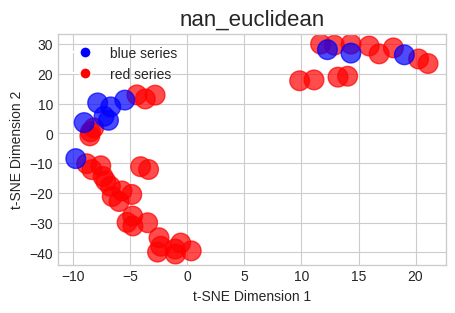

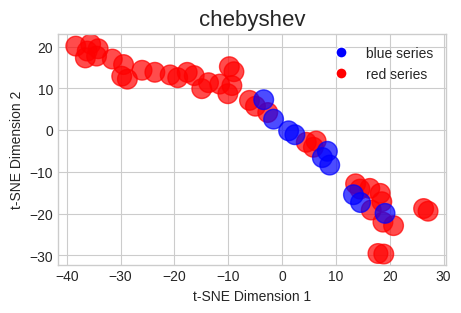

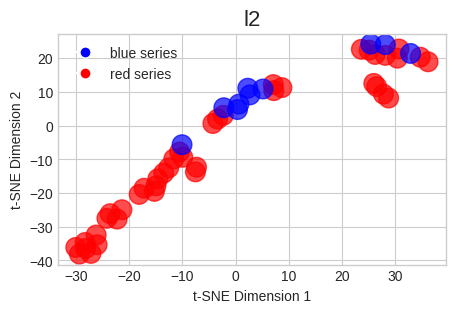

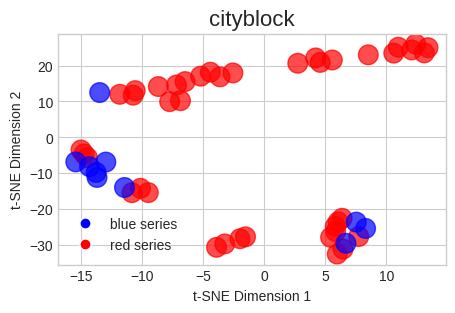

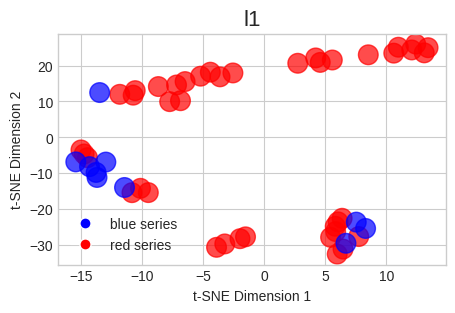

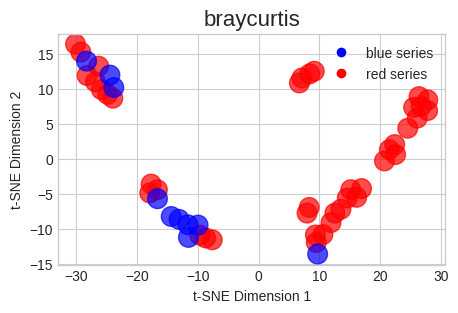

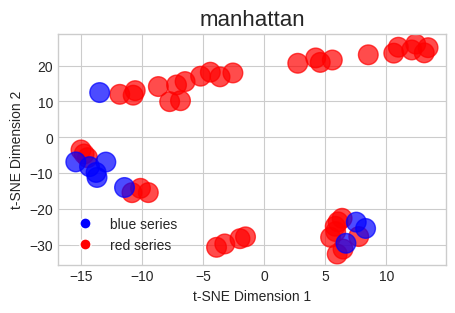

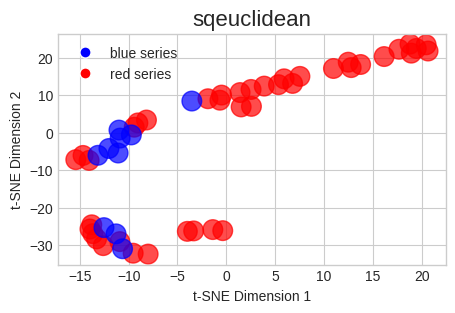

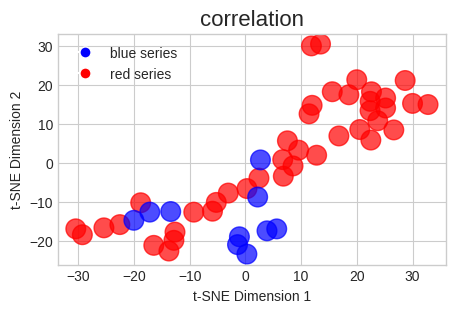

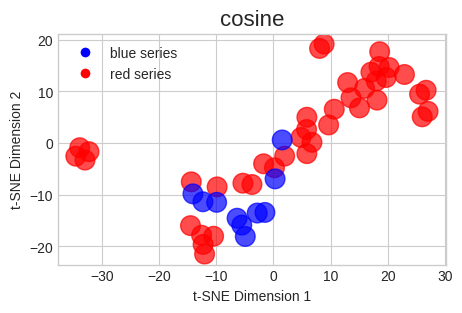

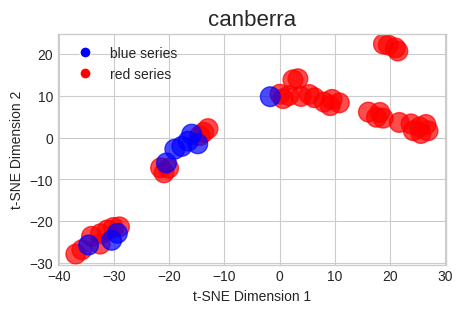

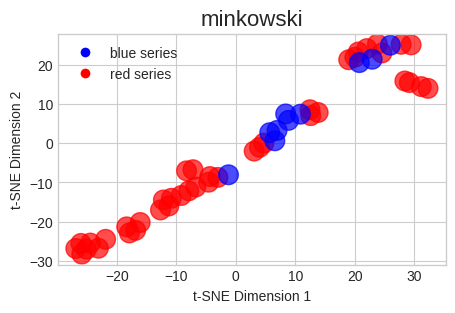

In [93]:
for metric in pdist_list:
    plot_tsne_similarity(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=5,
        scaler=StandardScaler,
        annotate=False,
        title=metric,
        figsize=(5, 3)
    )

### MinMax Scaler 

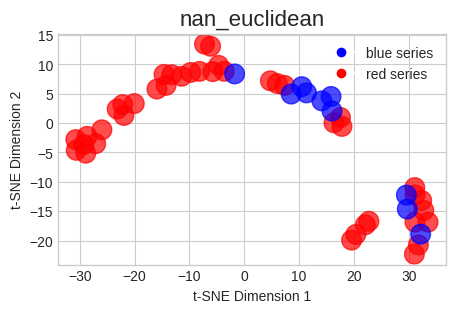

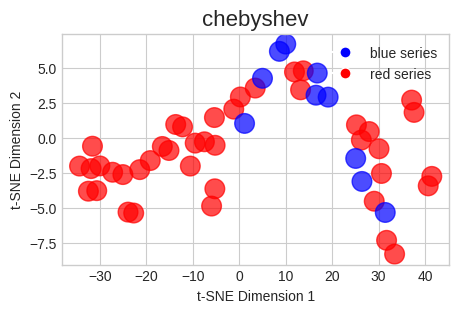

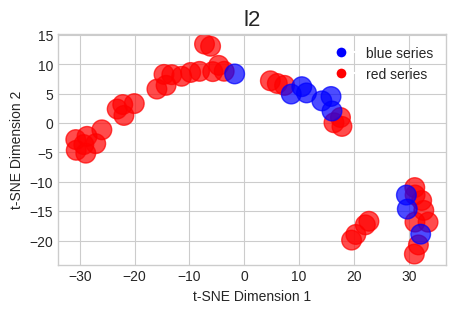

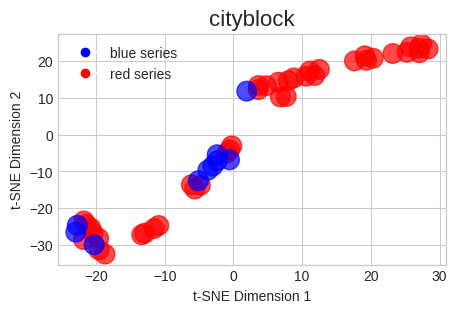

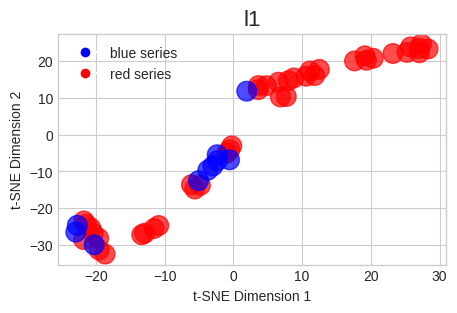

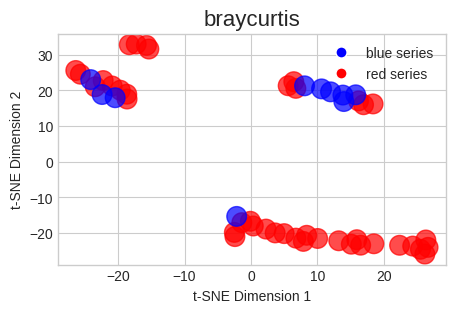

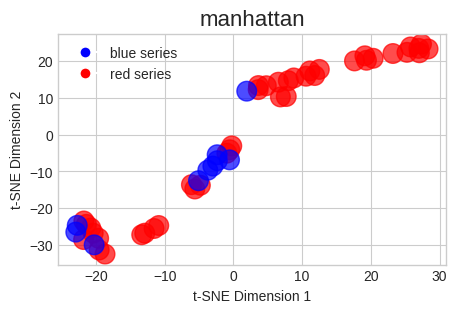

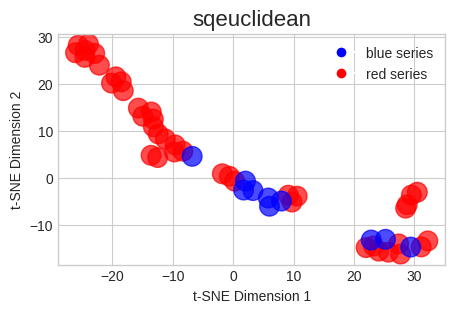

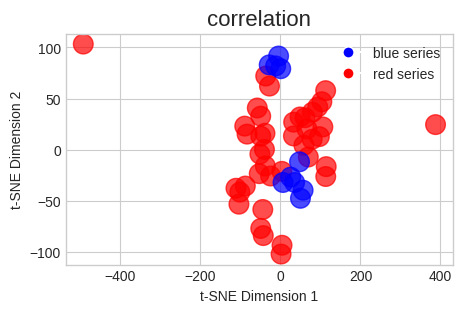

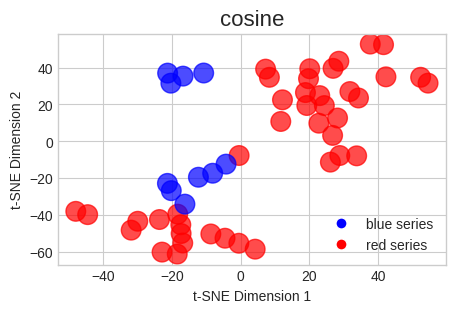

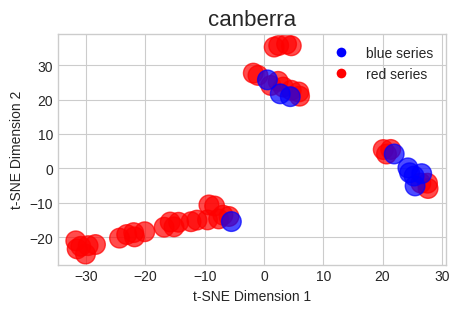

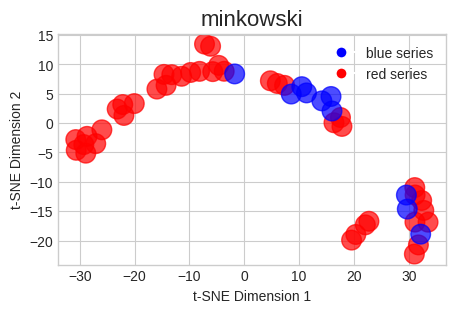

In [94]:
for metric in pdist_list:
    plot_tsne_similarity(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=5,
        scaler=MinMaxScaler,
        annotate=False,
        title=metric,
        figsize=(5, 3)
    )

### Perplexity = 10

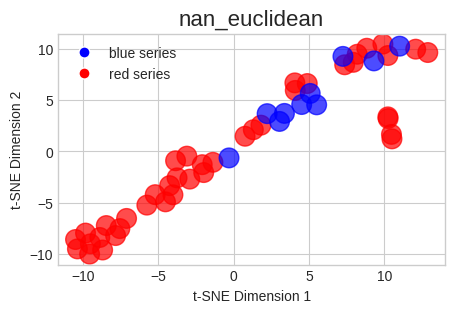

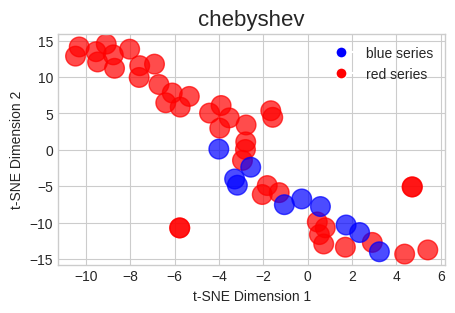

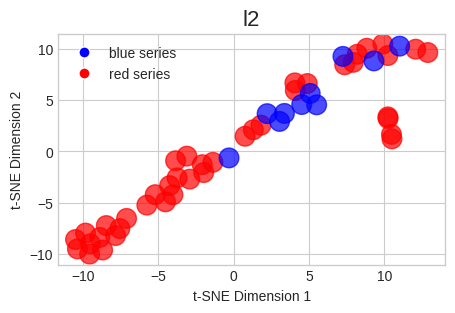

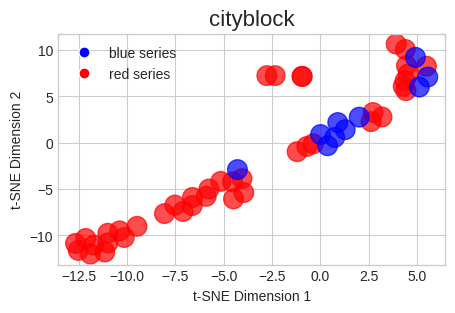

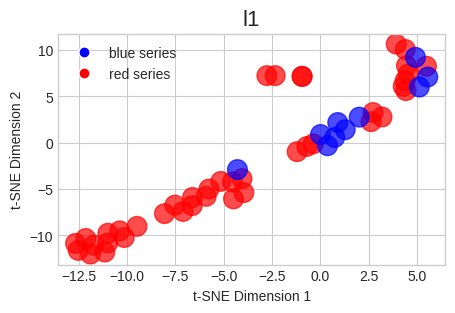

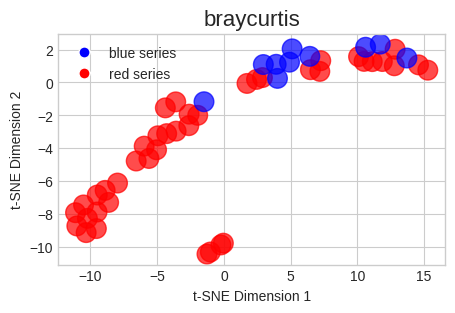

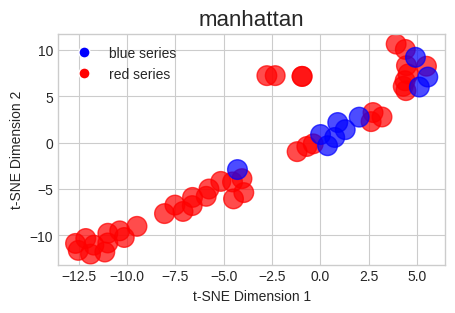

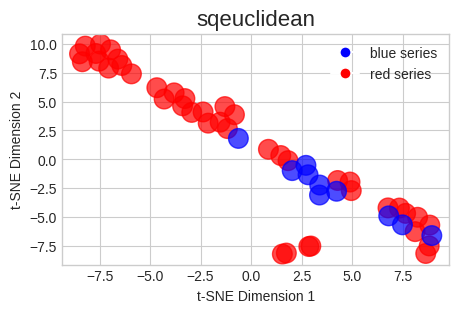

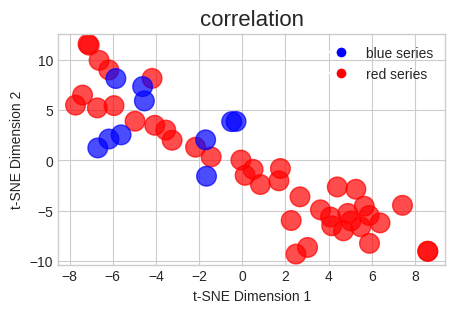

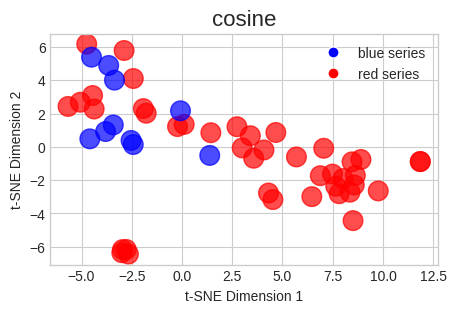

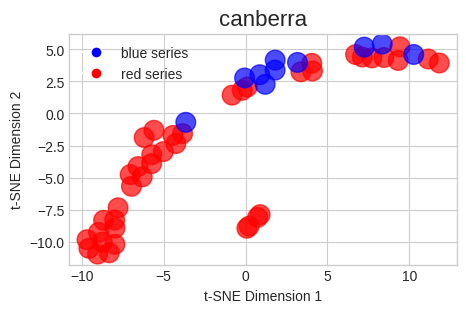

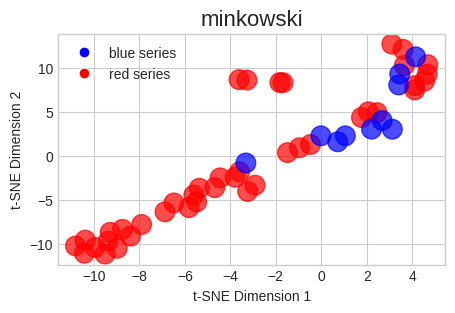

In [95]:
for metric in pdist_list:
    plot_tsne_similarity(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=10,
        scaler=StandardScaler,
        annotate=False,
        title=metric,
        figsize=(5, 3)
    )

### Perplexity = 2 

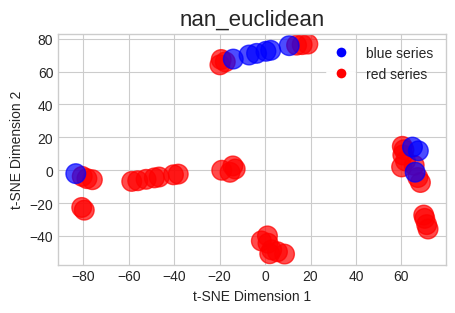

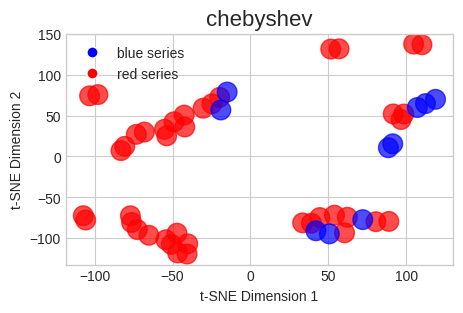

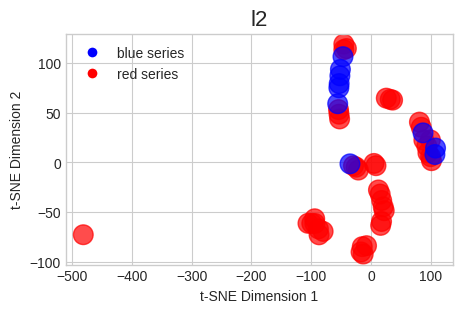

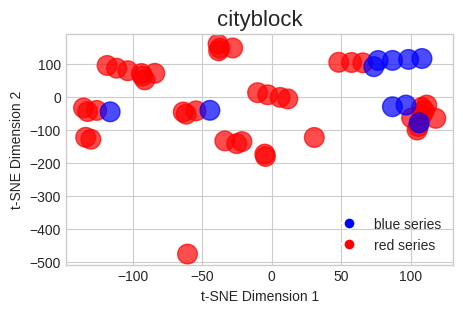

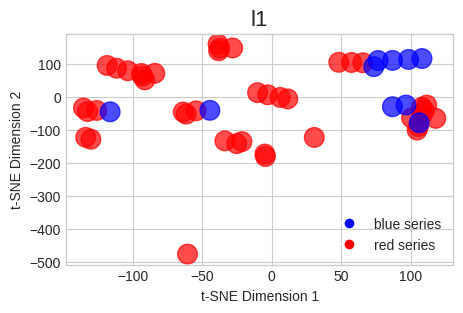

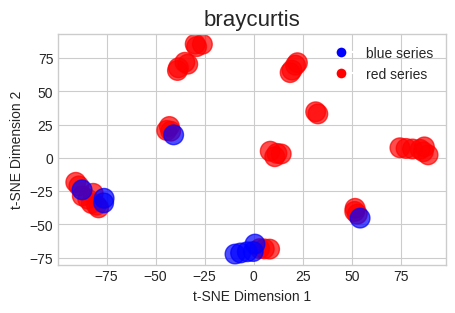

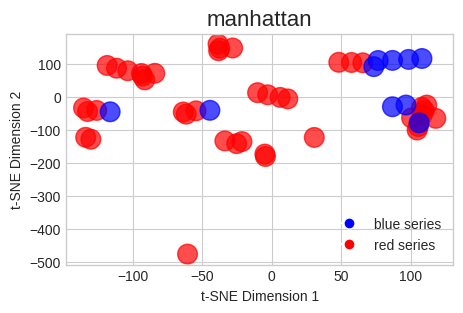

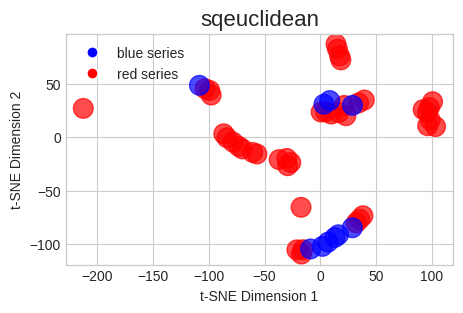

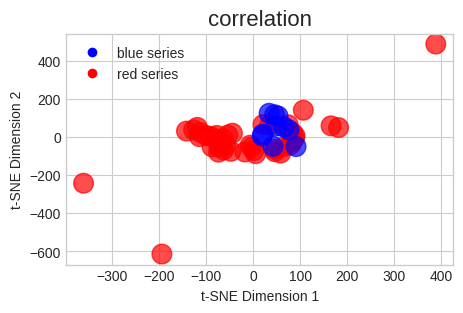

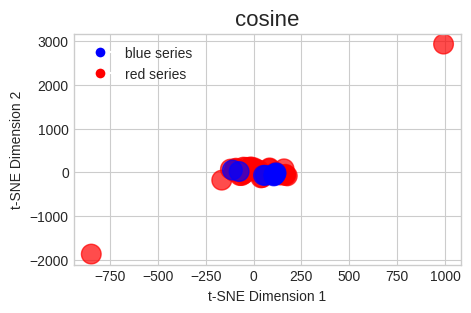

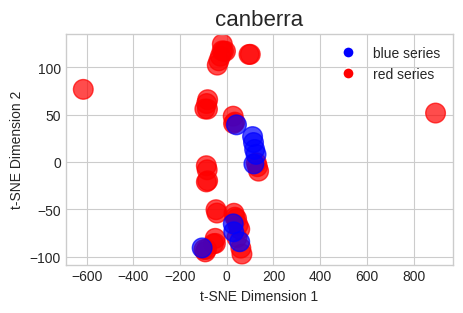

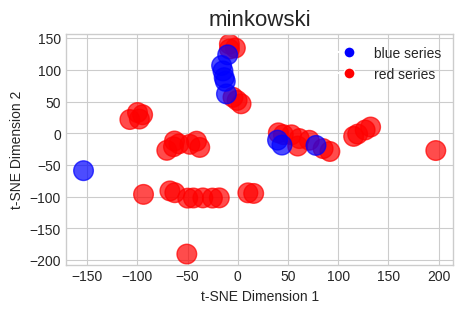

In [96]:
for metric in pdist_list:
    plot_tsne_similarity(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=2,
        scaler=StandardScaler,
        annotate=False,
        title=metric,
        figsize=(5, 3)
    )

## dastan_groups

In [114]:
chem_dict = {key: "dip" if i <= 5 else "bump" for i, key in enumerate(df2.columns)}
dastan_groups.update(chem_dict)

In [115]:
colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]
unique_values = list(set(dastan_groups.values()))
value_to_color = {value: colors[i] for i, value in enumerate(unique_values)}
color_dict = {key: value_to_color[value] for key, value in dastan_groups.items()}

In [117]:
for metric in pdist_list:
    plot_tsne_similarity_plotly(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=5,
        scaler=StandardScaler,
        group_dict=dastan_groups,
        title=metric,
        legend=False,
    )

visual_chem

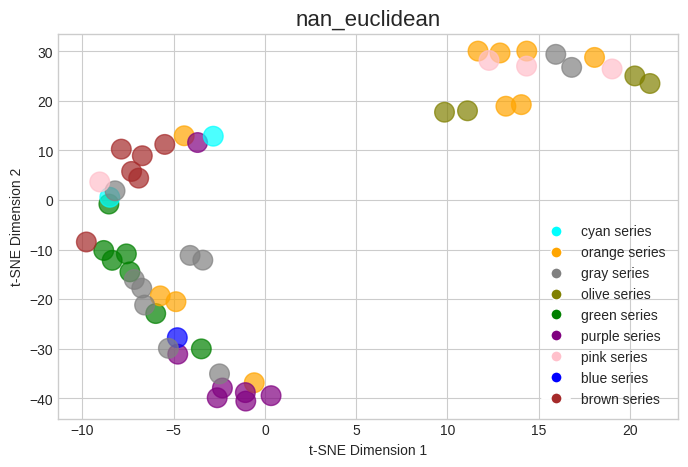

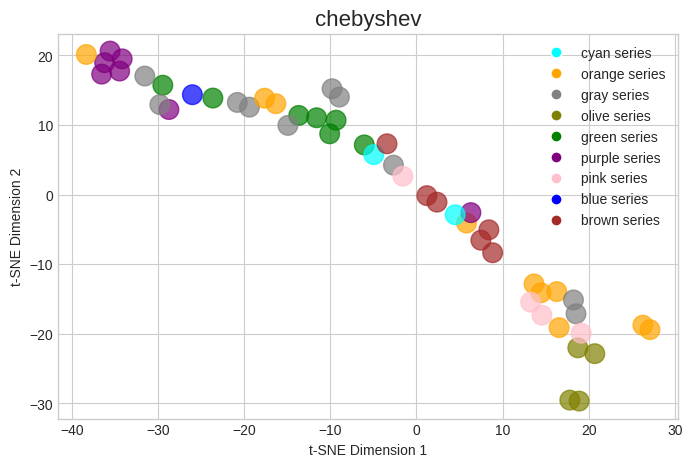

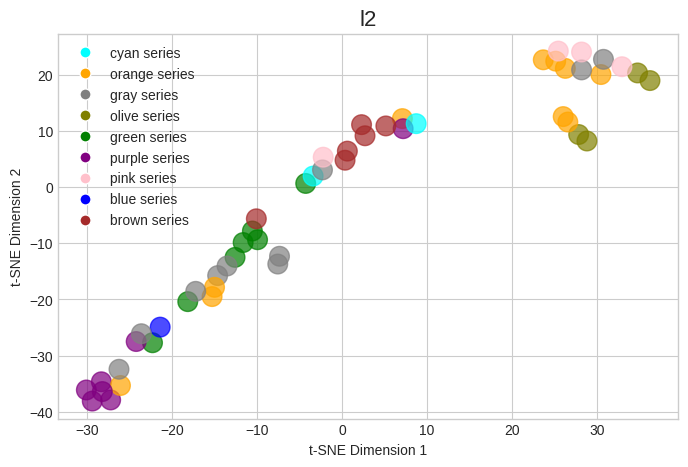

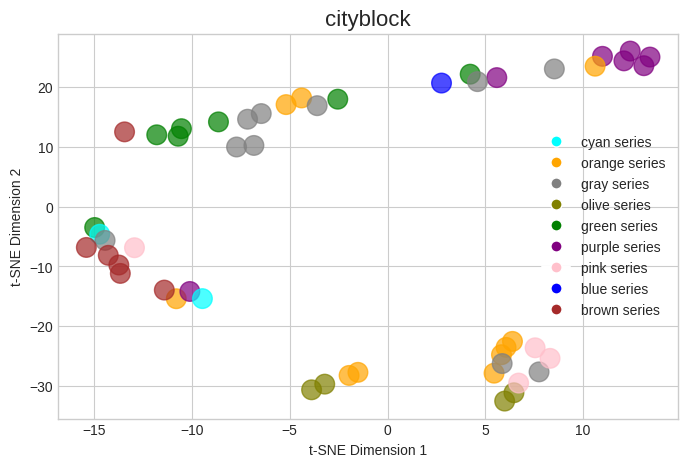

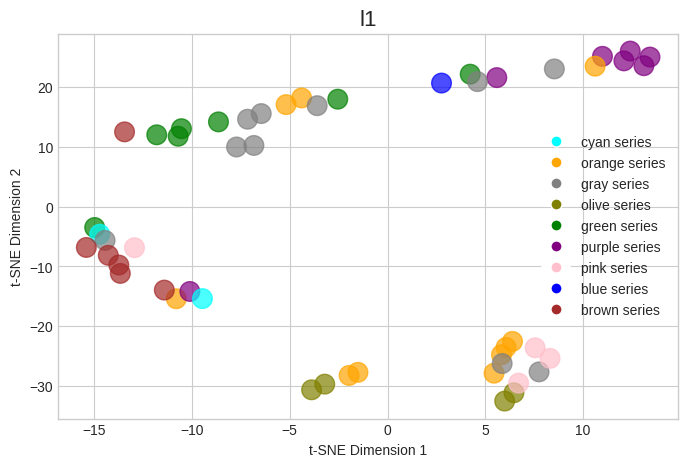

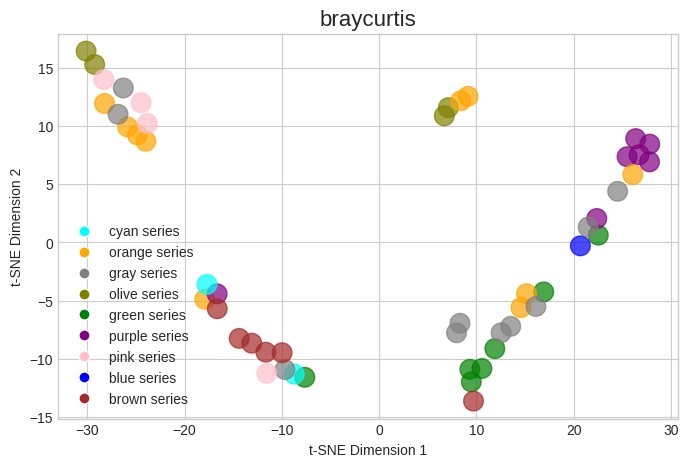

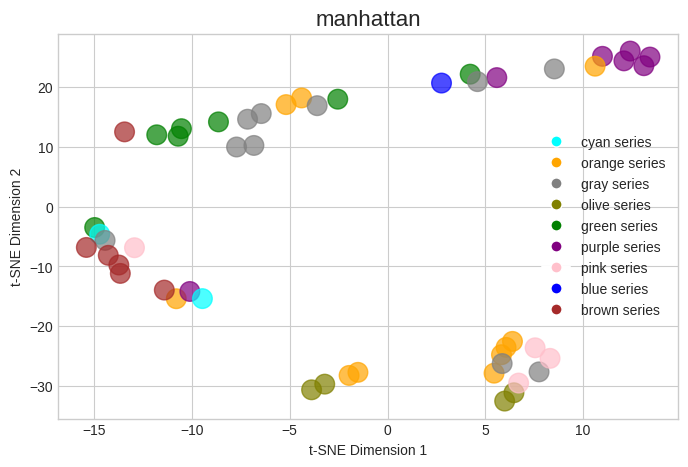

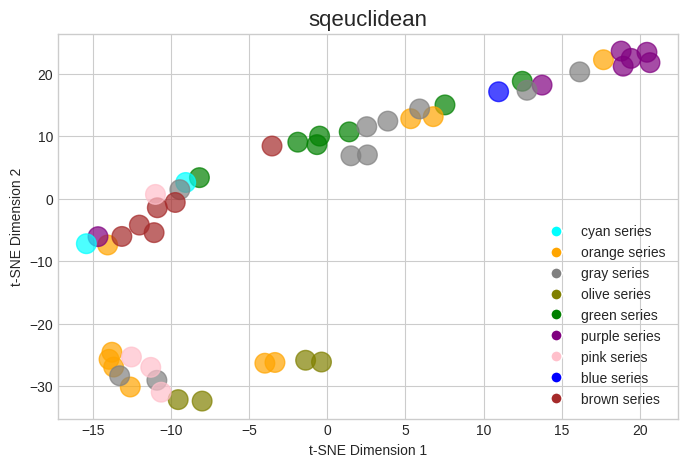

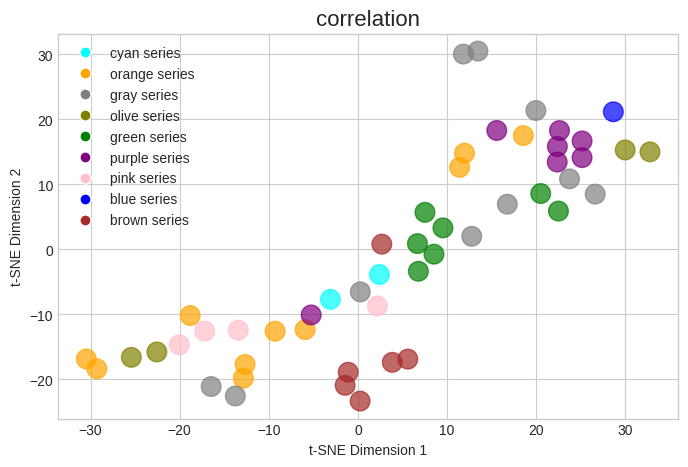

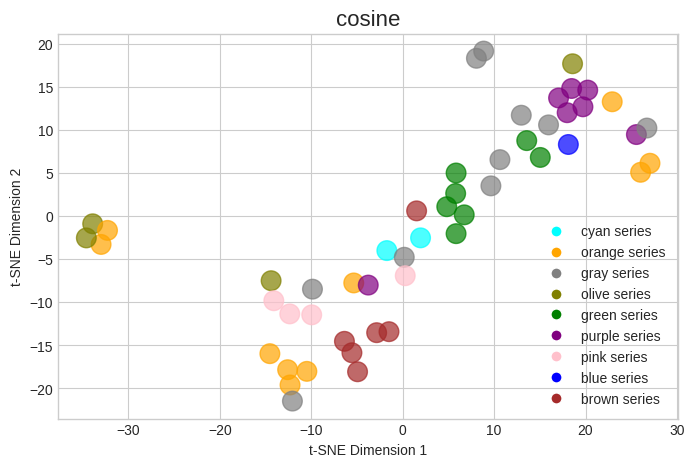

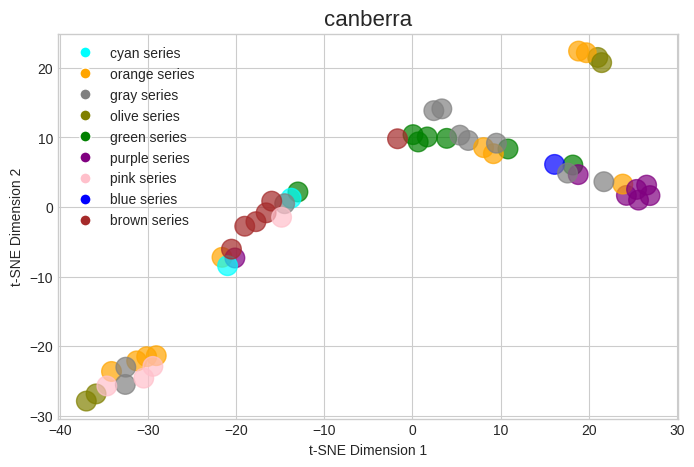

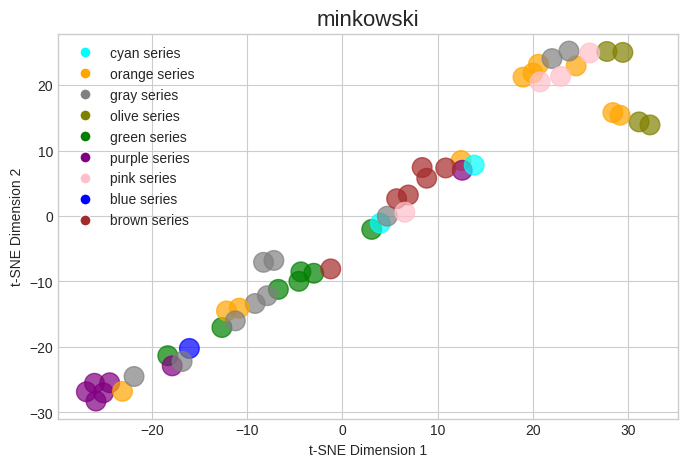

In [100]:
for metric in pdist_list:
    plot_tsne_similarity(
        df=df,
        metric=metric,
        color_dict=color_dict,
        perplexity=5,
        scaler=StandardScaler,
        annotate=False,
        title=metric,
    )